# Insurance Claim Prediction — Data Preprocessing

**Objective:** Clean, transform, and prepare the dataset for machine learning.

**Output:**
- `data/X_train.csv`, `data/X_test.csv`, `data/y_train.csv`, `data/y_test.csv`
- `models/preprocessor.pkl` — fitted ColumnTransformer for inference pipeline

**Target Variable:** `Claim` (0 = No Claim, 1 = Claim)

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
%matplotlib inline

print('Libraries loaded successfully!')

Libraries loaded successfully!


## 2. Load Dataset

In [2]:
df = pd.read_csv('../data/insurance_claim_dataset.csv')

print(f'Dataset shape: {df.shape}')
print(f'Total policyholders: {len(df):,}')
print(f'Total features: {df.shape[1]}')
df.head()

Dataset shape: (50000, 30)
Total policyholders: 50,000
Total features: 30


,Customer_ID,Age,Gender,Marital_Status,Occupation,Annual_Income,Credit_Score,Region,Vehicle_Type,Vehicle_Age,...,Coverage_Amount,Deductible,Annual_Premium,Policy_Duration,Urban_Rural,Parking_Type,Flood_Risk,Crime_Index,Claim,Claim_Amount
0,1,56,Female,Single,Employed,87430,694,South,Minivan,1,...,191266,2000,1991,12,Urban,Street,0,38,0,0
1,2,69,Female,Single,Student,43801,657,Northeast,Coupe,0,...,32813,1000,1390,12,Urban,Garage,0,84,1,1344
2,3,46,Male,Married,Retired,33036,556,South,SUV,1,...,27564,1000,1563,12,Urban,Driveway,0,70,0,0
3,4,32,Male,Single,Unemployed,39226,425,South,Truck,9,...,40270,500,1582,12,Rural,Garage,1,36,0,0
4,5,60,Male,Married,Employed,96541,661,South,SUV,1,...,139556,1500,2140,6,Rural,Street,1,44,0,0


## 3. Data Cleaning

### 3.1 Drop Identifier Column

In [3]:
df.drop(columns=['Customer_ID'], inplace=True)
print(f'Shape after dropping Customer_ID: {df.shape}')

Shape after dropping Customer_ID: (50000, 29)


### 3.2 Fix Occupation Inconsistencies

In [4]:
occup_before = df['Occupation'].value_counts()
mask = (df['Occupation'] == 'Student') & (df['Age'] > 30)
df.loc[mask, 'Occupation'] = 'Employed'
occup_after = df['Occupation'].value_counts()

print(f'Students reclassified to Employed (Age > 30): {mask.sum()}')
print('\nBefore → After:')
print(pd.DataFrame({'before': occup_before, 'after': occup_after}).fillna(0).astype(int))

Students reclassified to Employed (Age > 30): 4063

Before → After:
               before  after
Occupation                  
Employed        27361  31424
Retired          5980   5980
Self-Employed    7437   7437
Student          5117   1054
Unemployed       4105   4105


### 3.3 Handle Claim_Amount

Only non-zero for claimants (Claim=1). Set to NaN for non-claimants to avoid leakage; drop it from features.

In [5]:
print(f'Claim_Amount non-zero for Claim=0: {(df.loc[df["Claim"]==0, "Claim_Amount"] > 0).sum()}')
print(f'Claim_Amount zero for Claim=1:    {(df.loc[df["Claim"]==1, "Claim_Amount"] == 0).sum()}')
df_clean = df.drop(columns=['Claim_Amount']).copy()

Claim_Amount non-zero for Claim=0: 0
Claim_Amount zero for Claim=1:    0


### 3.4 Check Missing Values & Duplicates

In [6]:
missing = df_clean.isnull().sum()
missing = missing[missing > 0]
if len(missing) > 0:
    print('Columns with missing values:')
    print(missing)
else:
    print('No missing values found!')

duplicates = df_clean.duplicated().sum()
print(f'Duplicate rows: {duplicates}')

No missing values found!
Duplicate rows: 0


### 3.5 Outlier Detection (IQR Method)

In [7]:
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.difference(['Claim']).tolist()

outlier_stats = []
for col in numeric_cols:
    q1 = df_clean[col].quantile(0.25)
    q3 = df_clean[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()
    outlier_stats.append({
        'feature': col, 'outliers': outliers,
        'pct': outliers / len(df_clean) * 100
    })

outlier_df = pd.DataFrame(outlier_stats)
outlier_df = outlier_df[outlier_df['outliers'] > 0].sort_values('outliers', ascending=False)
print(f'Features with outliers ({len(outlier_df)}):')
display(outlier_df.reset_index(drop=True))

Features with outliers (13):


,feature,outliers,pct
0,Previous_Accidents,11645,23.290
1,Flood_Risk,9962,19.924
2,Coverage_Amount,6502,13.004
3,Policy_Duration,5016,10.032
4,Vehicle_Age,3036,6.072
5,Engine_Size,1069,2.138
6,Traffic_Violations,688,1.376
7,Previous_Claims,325,0.650
8,Annual_Premium,233,0.466
9,Annual_Mileage,177,0.354


### 3.6 Winsorize Outliers

Cap to IQR bounds instead of removing rows (preserves dataset size).

In [8]:
capped_total = 0
for col in outlier_df['feature']:
    q1 = df_clean[col].quantile(0.25)
    q3 = df_clean[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    before = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()
    df_clean[col] = df_clean[col].clip(lower=lower, upper=upper)
    capped_total += before

print(f'Total outlier values capped: {capped_total}')
print(f'Shape: {df_clean.shape}')

Total outlier values capped: 38847


Shape: (50000, 28)


## 4. Target Variable Analysis

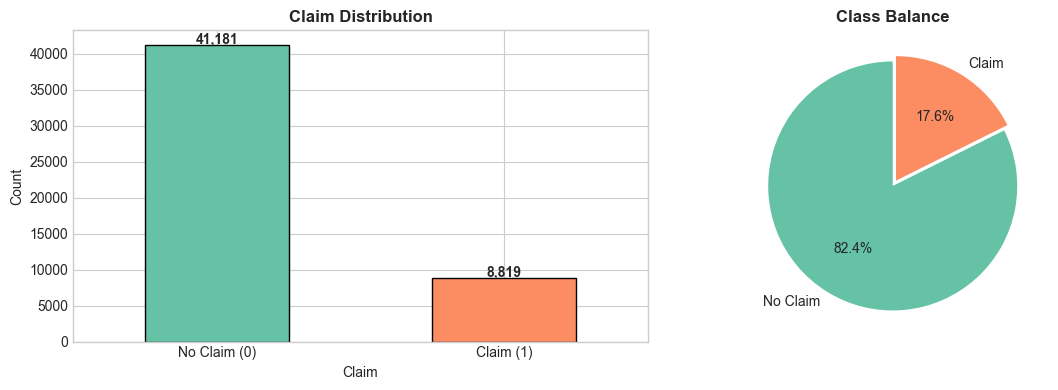

Claim rate: 17.64%
Imbalance ratio: 4.67:1


In [9]:
claim_counts = df_clean['Claim'].value_counts().reindex([0, 1], fill_value=0)
claim_pct = df_clean['Claim'].value_counts(normalize=True).reindex([0, 1], fill_value=0) * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
colors = ['#66c2a5', '#fc8d62']

claim_counts.plot(kind='bar', ax=ax1, color=colors, edgecolor='black')
ax1.set_xticks([0, 1])
ax1.set_xticklabels(['No Claim (0)', 'Claim (1)'], rotation=0)
ax1.set_ylabel('Count')
ax1.set_title('Claim Distribution', fontweight='bold')
for i, v in enumerate(claim_counts):
    ax1.text(i, v + 200, f'{v:,}', ha='center', fontweight='bold')

ax2.pie(claim_pct, labels=['No Claim', 'Claim'], autopct='%1.1f%%',
        colors=colors, startangle=90, explode=(0, 0.05))
ax2.set_title('Class Balance', fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/figures/01_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Claim rate: {df_clean["Claim"].mean()*100:.2f}%')
print(f'Imbalance ratio: {claim_counts[0]/claim_counts[1]:.2f}:1')

## 5. Feature Engineering

In [10]:
# Age groups
age_bins = [17, 25, 35, 50, 65, 100]
age_labels = ['Young', 'YoungAdult', 'MiddleAge', 'Senior', 'Elder']
df_clean['Age_Group'] = pd.cut(df_clean['Age'], bins=age_bins, labels=age_labels)

# Driving experience ratio (experience vs age)
df_clean['Exp_Ratio'] = (df_clean['Driving_Experience'] / df_clean['Age'].replace(0, np.nan)).clip(0, 1)

# Risk score: combination of violations, accidents, claims
df_clean['Risk_Score'] = (
    df_clean['Traffic_Violations'] * 3 +
    df_clean['Previous_Accidents'] * 2 +
    df_clean['Previous_Claims'] * 2
)

# Premium-to-income ratio
df_clean['Premium_Income_Ratio'] = df_clean['Annual_Premium'] / df_clean['Annual_Income'].replace(0, np.nan)

# Vehicle age category
df_clean['Vehicle_Is_Old'] = (df_clean['Vehicle_Age'] >= 3).astype(int)

# High-risk driver indicator
df_clean['High_Risk_Driver'] = (df_clean['Traffic_Violations'] > 2).astype(int)

print('Engineered features added:')
print('  - Age_Group (categorical, 5 bins)')
print('  - Exp_Ratio (Driving_Experience / Age)')
print('  - Risk_Score (3*Violations + 2*Accidents + 2*Claims)')
print('  - Premium_Income_Ratio (Premium / Income)')
print('  - Vehicle_Is_Old (Vehicle_Age >= 3)')
print('  - High_Risk_Driver (Violations > 2)')
print(f'\nNew shape: {df_clean.shape}')

Engineered features added:
  - Age_Group (categorical, 5 bins)
  - Exp_Ratio (Driving_Experience / Age)
  - Risk_Score (3*Violations + 2*Accidents + 2*Claims)
  - Premium_Income_Ratio (Premium / Income)
  - Vehicle_Is_Old (Vehicle_Age >= 3)
  - High_Risk_Driver (Violations > 2)

New shape: (50000, 34)


## 6. Feature-Target Correlation

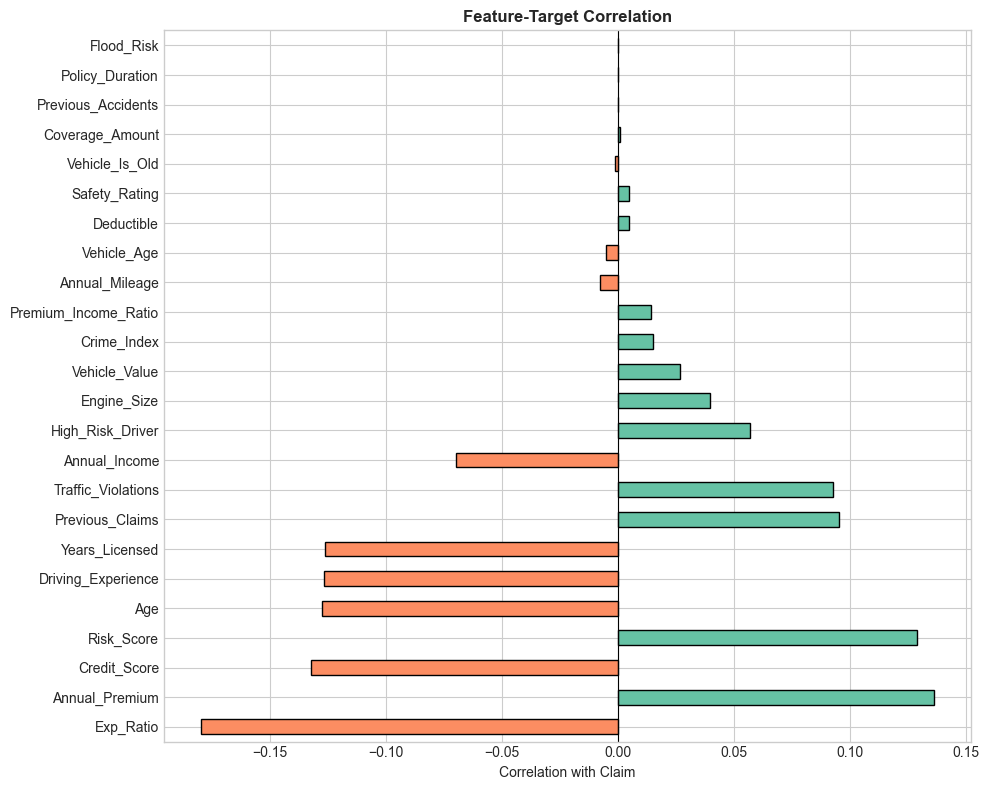

Top 5 features correlated with Claim:
Exp_Ratio        -0.179843
Annual_Premium    0.136123
Credit_Score     -0.132112
Risk_Score        0.128594
Age              -0.127458


In [11]:
numeric_df = df_clean.select_dtypes(include=[np.number])
corr = numeric_df.corr()['Claim'].drop('Claim').sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
colors_bar = ['#fc8d62' if v < 0 else '#66c2a5' for v in corr.values]
corr.plot(kind='barh', ax=ax, color=colors_bar, edgecolor='black')
ax.set_xlabel('Correlation with Claim')
ax.set_title('Feature-Target Correlation', fontweight='bold')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('../reports/figures/01_feature_target_corr.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 5 features correlated with Claim:')
print(corr.head(5).to_string())

## 7. Separate Features & Target

In [12]:
target = 'Claim'
y = df_clean[target]
X = df_clean.drop(columns=[target])

print(f'Features: {X.shape}')
print(f'Target:   {y.shape}')

Features: (50000, 33)
Target:   (50000,)


## 8. Identify Column Types

Split into numeric (scale) and categorical (encode) columns.

In [13]:
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

print(f'Numeric ({len(numeric_features)}):      {numeric_features}')
print(f'Categorical ({len(categorical_features)}): {categorical_features}')

Numeric (24):      ['Age', 'Annual_Income', 'Credit_Score', 'Vehicle_Age', 'Vehicle_Value', 'Annual_Mileage', 'Engine_Size', 'Safety_Rating', 'Driving_Experience', 'Years_Licensed', 'Previous_Claims', 'Previous_Accidents', 'Traffic_Violations', 'Coverage_Amount', 'Deductible', 'Annual_Premium', 'Policy_Duration', 'Flood_Risk', 'Crime_Index', 'Exp_Ratio', 'Risk_Score', 'Premium_Income_Ratio', 'Vehicle_Is_Old', 'High_Risk_Driver']
Categorical (9): ['Gender', 'Marital_Status', 'Occupation', 'Region', 'Vehicle_Type', 'Policy_Type', 'Urban_Rural', 'Parking_Type', 'Age_Group']


## 9. Build Preprocessing Pipeline

- **Numeric:** Median imputation → StandardScaler
- **Categorical:** Mode imputation → OneHotEncoder (drop first)

In [14]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='drop'
)

print('Preprocessing pipeline built!')

Preprocessing pipeline built!


## 10. Train-Test Split (Stratified 80-20)

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: X={X_train.shape}, y={y_train.shape} (claim rate: {y_train.mean()*100:.2f}%)')
print(f'Test:  X={X_test.shape}, y={y_test.shape} (claim rate: {y_test.mean()*100:.2f}%)')

Train: X=(40000, 33), y=(40000,) (claim rate: 17.64%)
Test:  X=(10000, 33), y=(10000,) (claim rate: 17.64%)


## 11. Fit Preprocessor & Transform Data

In [16]:
print('Fitting preprocessor on training data...')
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Get feature names after transformation
cat_feature_names = preprocessor.named_transformers_['cat']\
    .named_steps['onehot'].get_feature_names_out(categorical_features)
all_feature_names = list(numeric_features) + list(cat_feature_names)

X_train_processed = pd.DataFrame(X_train_processed, columns=all_feature_names)
X_test_processed = pd.DataFrame(X_test_processed, columns=all_feature_names)

print(f'Processed train shape: {X_train_processed.shape}')
print(f'Processed test shape:  {X_test_processed.shape}')
print(f'Total features after encoding: {len(all_feature_names)}')

Fitting preprocessor on training data...


Processed train shape: (40000, 49)
Processed test shape:  (10000, 49)
Total features after encoding: 49


## 12. Save Outputs

Saved files are consumed by downstream notebooks.

In [17]:
os.makedirs('../models', exist_ok=True)

X_train_processed.to_csv('../data/X_train.csv', index=False)
X_test_processed.to_csv('../data/X_test.csv', index=False)
y_train.to_csv('../data/y_train.csv', index=True, header=True)
y_test.to_csv('../data/y_test.csv', index=True, header=True)

with open('../models/preprocessor.pkl', 'wb') as f:
    pickle.dump(preprocessor, f)

# Also save feature names for reference
feature_df = pd.DataFrame({'feature': all_feature_names})
feature_df.to_csv('../data/feature_names.csv', index=False)

print('Files saved:')
print('  - data/X_train.csv')
print('  - data/X_test.csv')
print('  - data/y_train.csv')
print('  - data/y_test.csv')
print('  - models/preprocessor.pkl')
print('  - data/feature_names.csv')
print(f'\nPreprocessing complete!')

Files saved:
  - data/X_train.csv
  - data/X_test.csv
  - data/y_train.csv
  - data/y_test.csv
  - models/preprocessor.pkl
  - data/feature_names.csv

Preprocessing complete!
